In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
from imblearn.over_sampling import SMOTE

In [59]:

df = pd.read_csv("trainingset_v1d1_metadata.csv")
df

,event_time,ifo,peak_time,peak_time_ns,start_time,start_time_ns,duration,search,process_id,event_id,...,chisq_dof,param_one_name,param_one_value,gravityspy_id,label,sample_type,url1,url2,url3,url4
0,1.134216e+09,L1,1134216192,931639909,1134216192,832031011,0.18750,Omicron,0,21,...,0,phase,-2.72902,zmIdpucyOG,Whistle,train,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
1,1.129360e+09,L1,1129359781,558593034,1129359781,47851085,0.94238,Omicron,0,107,...,0,phase,1.10682,zWFRqqDxwv,Whistle,test,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
2,1.127425e+09,L1,1127425468,976317882,1127425468,960937023,0.04688,Omicron,0,218,...,0,phase,-0.83099,zKCTakFVcf,Whistle,train,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
3,1.132637e+09,L1,1132636755,365233898,1132636754,951172113,0.82422,Omicron,0,88,...,0,phase,0.76242,z14BdoiFZS,Whistle,validation,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
4,1.132036e+09,L1,1132035853,197264909,1132035852,933837890,2.00366,Omicron,0,16,...,0,phase,-0.31161,yyjqLCtAmO,Whistle,validation,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7961,1.127688e+09,L1,1127688297,710937023,1127688292,0,9.00391,Omicron,0,182,...,0,phase,-2.48491,K4lUik19zL,Extremely_Loud,train,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
7962,1.128422e+09,L1,1128421736,324218034,1128421736,304687023,0.03906,Omicron,0,396,...,0,phase,1.32651,EkRSkrpPet,Helix,validation,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
7963,1.164774e+09,H1,1164773536,433593034,1164773535,911376953,1.16675,OMICRON,0,1817,...,0,phase,2.72929,xyLhvRKzzX,1080Lines,train,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...
7964,1.163790e+09,L1,1163789867,496093034,1163789867,476562023,0.10156,OMICRON,0,501,...,0,phase,0.66486,lshKvhcRcT,Violin_Mode,train,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...,https://panoptes-uploads.zooniverse.org/produc...


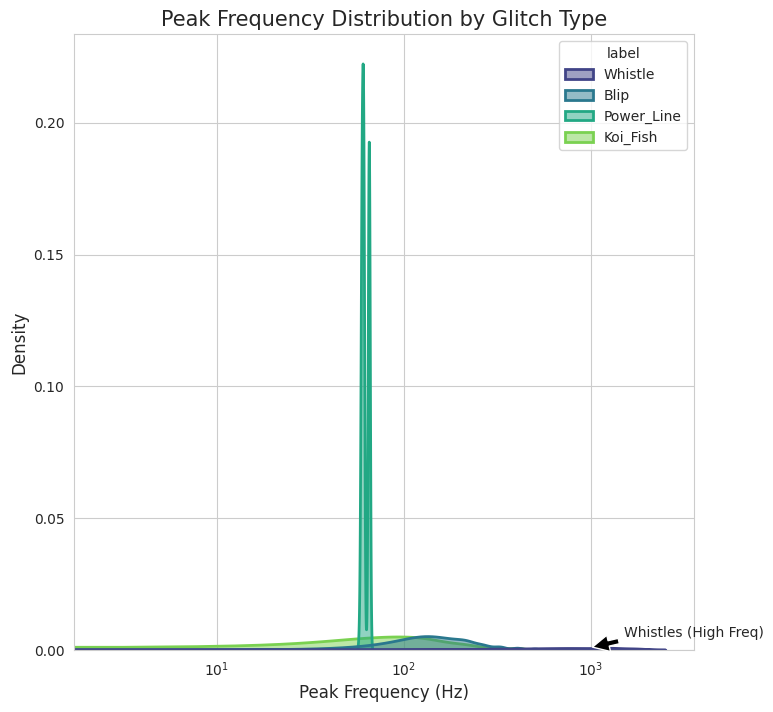

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
sns.set_style("whitegrid")

target_labels = ['Blip', 'Whistle', 'Koi_Fish', 'Power_Line']
filtered_df = df[df['label'].isin(target_labels)]

sns.kdeplot(data=filtered_df, x='peak_frequency', hue='label', fill=True, common_norm=False, palette='viridis', alpha=.5, linewidth=2)

plt.title('Peak Frequency Distribution by Glitch Type', fontsize=15)
plt.xlabel('Peak Frequency (Hz)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xscale('log')

plt.annotate('Whistles (High Freq)', xy=(1000, 0.001), xytext=(1500, 0.005),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

In [61]:
#The KDE plot illustrates the (Digital Signature) for each glitch type, we observe that Power_Line glitches are highly concentrated at a specific frequency, while Whistle glitches extend into very high-frequency ranges exceeding \bm{10^{3}} Hz, this fundamental difference enables us to distinguish terrestrial noise from actual gravitational waves.

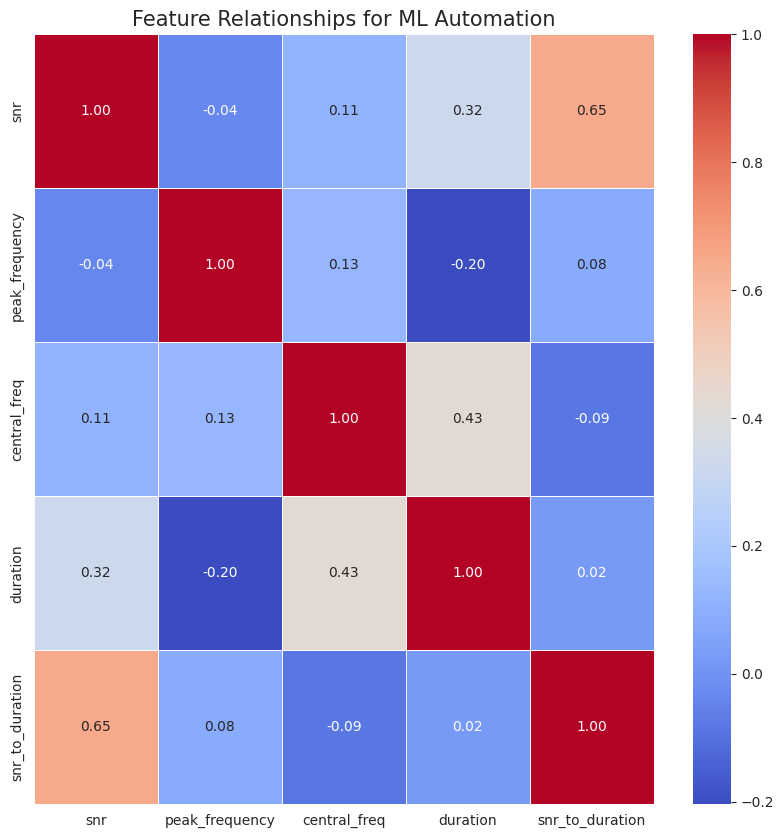

In [62]:
df['snr_to_duration'] = df['snr'] / df['duration']

plt.figure(figsize=(10,10))

features = ['snr', 'peak_frequency', 'central_freq', 'duration', 'snr_to_duration']
corr_matrix = df[features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Relationships for ML Automation', fontsize=15)
plt.show()

In [63]:
#Developed an integrated signal processing and filtering pipeline to isolate gravitational waves from terrestrial noise through:
#1.Signal Profiling & Engineering: Leveraged KDE plots and the \bm{snr\_to\_duration} feature to distinguish unique glitch 'fingerprints' from cosmic signals.
#2.Data Optimization: Utilized Correlation Heatmaps to identify key physical variables, streamlining ML automation and reducing manual intervention.
#3.Spatial Verification: Cross-correlated noise patterns between Hanford and Livingston observatories to filter out localized environmental interference.

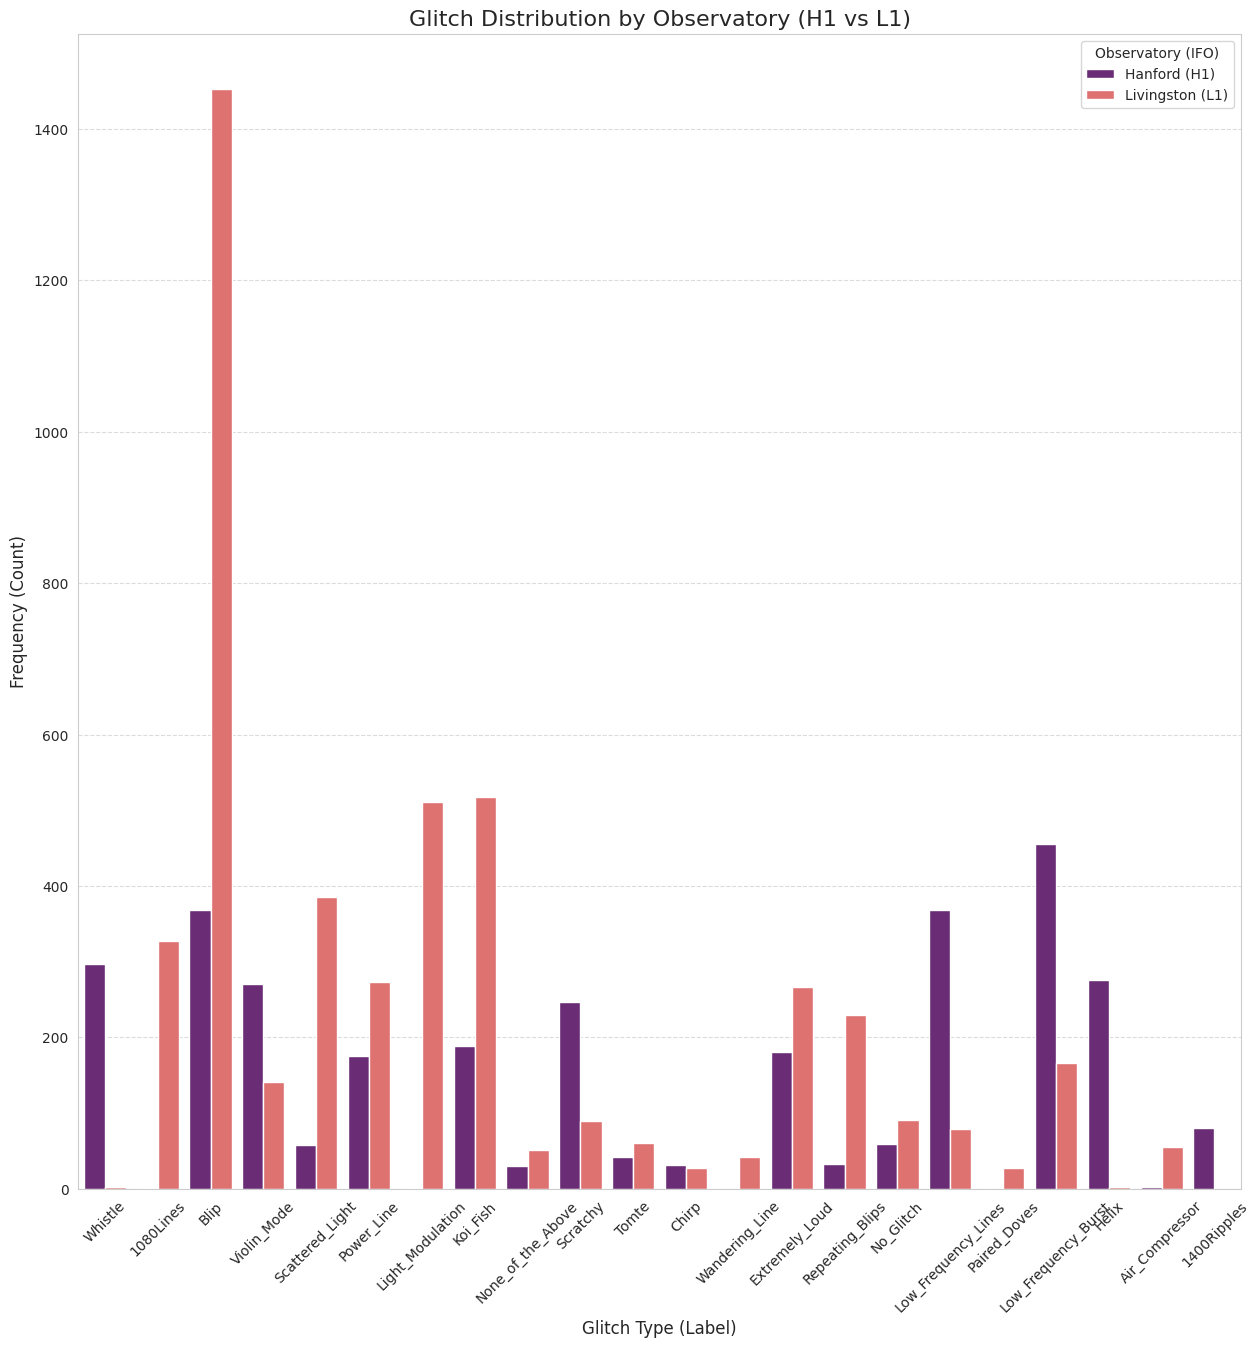

In [64]:
plt.figure(figsize=(15,15))

sns.countplot(data=df, x='label', hue='ifo', palette='magma')

plt.title('Glitch Distribution by Observatory (H1 vs L1)', fontsize=16)
plt.xlabel('Glitch Type (Label)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Observatory (IFO)', labels=['Hanford (H1)', 'Livingston (L1)'])

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [65]:
#Action: A Grouped Bar Chart was generated to compare the frequency of glitch types between the Hanford (H1) and Livingston (L1) observatories.
#Goal: To identify False Alarms, if a specific glitch type is predominant at only one site, it provides conclusive evidence of localized environmental noise (traffic or weather) rather than a cosmic event,
#as real gravitational waves should be detected simultaneously across both observatories.

<Figure size 2000x2000 with 0 Axes>

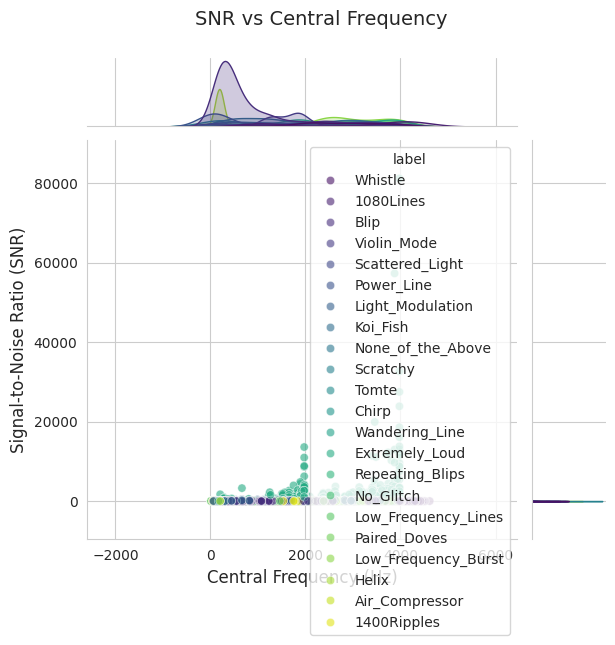

In [66]:
df['freq_stability'] = (df['central_freq'] * df['duration'])
plt.figure(figsize=(20,20))

grid = sns.jointplot(data=df, x='central_freq', y='snr', kind='scatter',
                     hue='label', palette='viridis', alpha=0.6)

grid.fig.suptitle('SNR vs Central Frequency', fontsize=14)
grid.fig.subplots_adjust(top=0.9)
grid.set_axis_labels('Central Frequency (Hz)', 'Signal-to-Noise Ratio (SNR)', fontsize=12)

plt.show()

In [67]:
#The plot visualizes signal clusters and identifies outliers that might represent (false alarms) caused by the local environment by using:

#1.Created the freq_stability feature by multiplying the central frequency by the duratio

#2.To distinguish high-energy instantaneous noise from stable events, ensuring Data Integrity

#3.Used jointplot to combine a scatter plot with marginal histograms on the axes.

/tmp/ipykernel_3512/3146399330.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='snr_to_duration', palette='viridis')


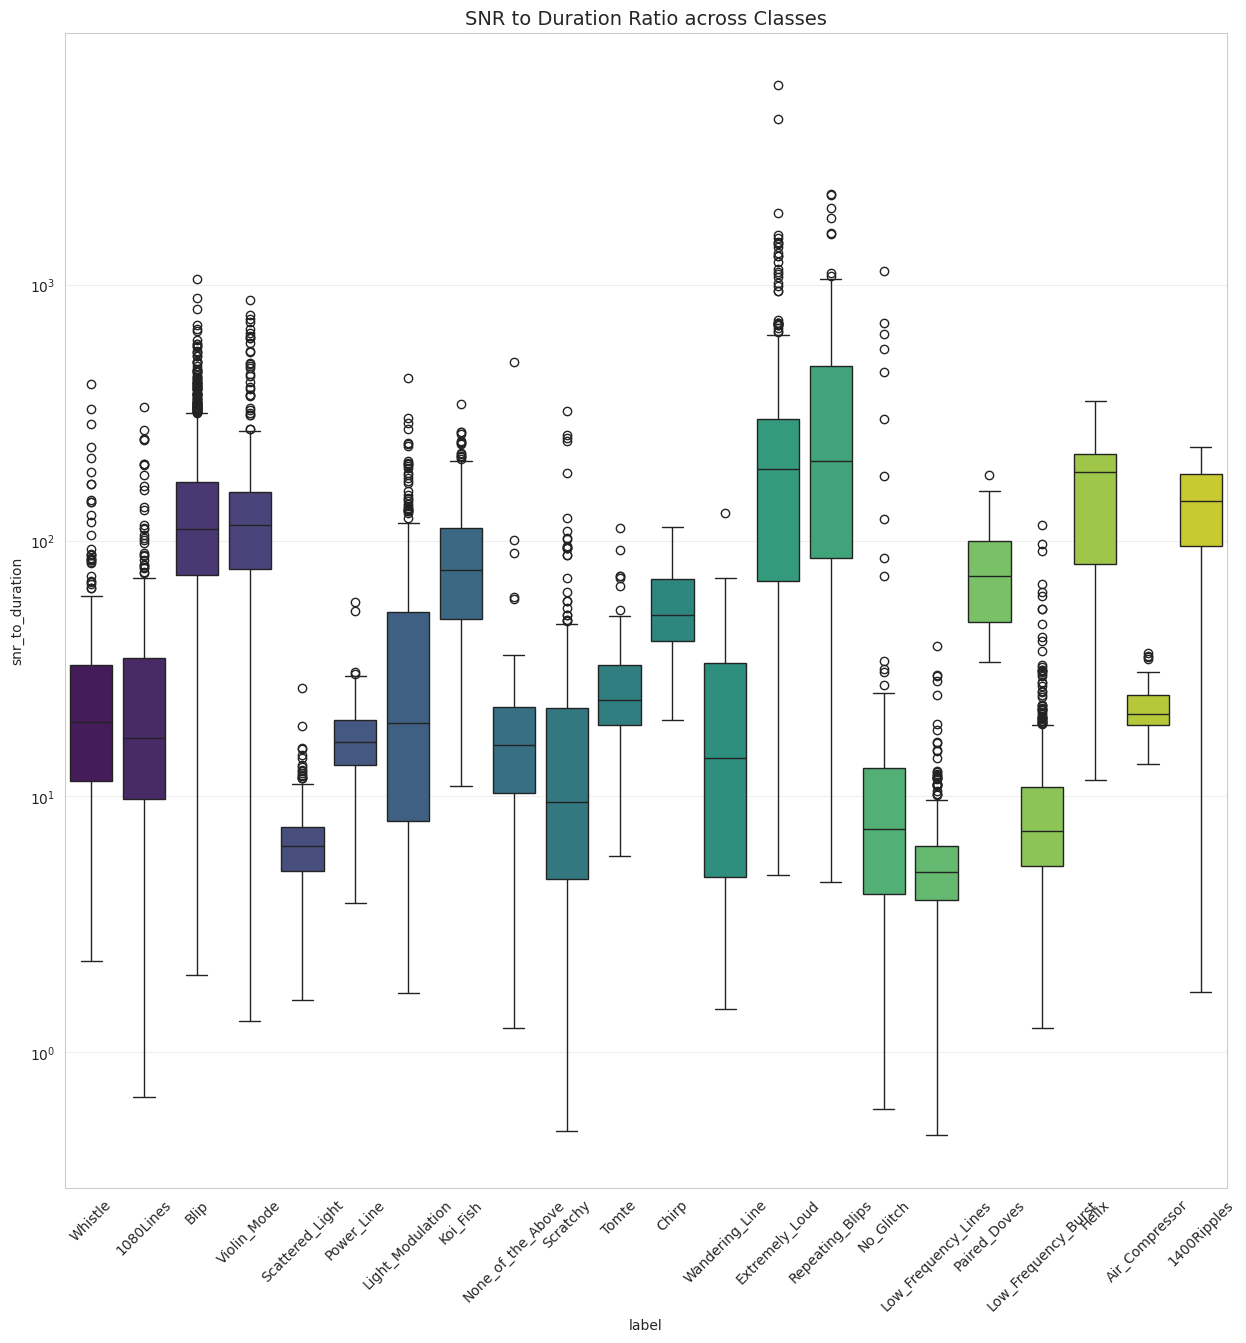

In [68]:
df['snr_to_duration'] = df['snr'] / df['duration']


plt.figure(figsize=(15,15))
sns.boxplot(data=df, x='label', y='snr_to_duration', palette='viridis')

plt.title('SNR to Duration Ratio across Classes', fontsize=14)
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [69]:
#This feature aims to distinguish between terrestrial noise and cosmic signals ,glitches are typically characterized
#by high energy (SNR) occurring over a veryshort time (Duration), whereas actual cosmic signals are more sustained and balanced

/tmp/ipykernel_3512/1508830061.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label', y='freq_stability', palette='magma')


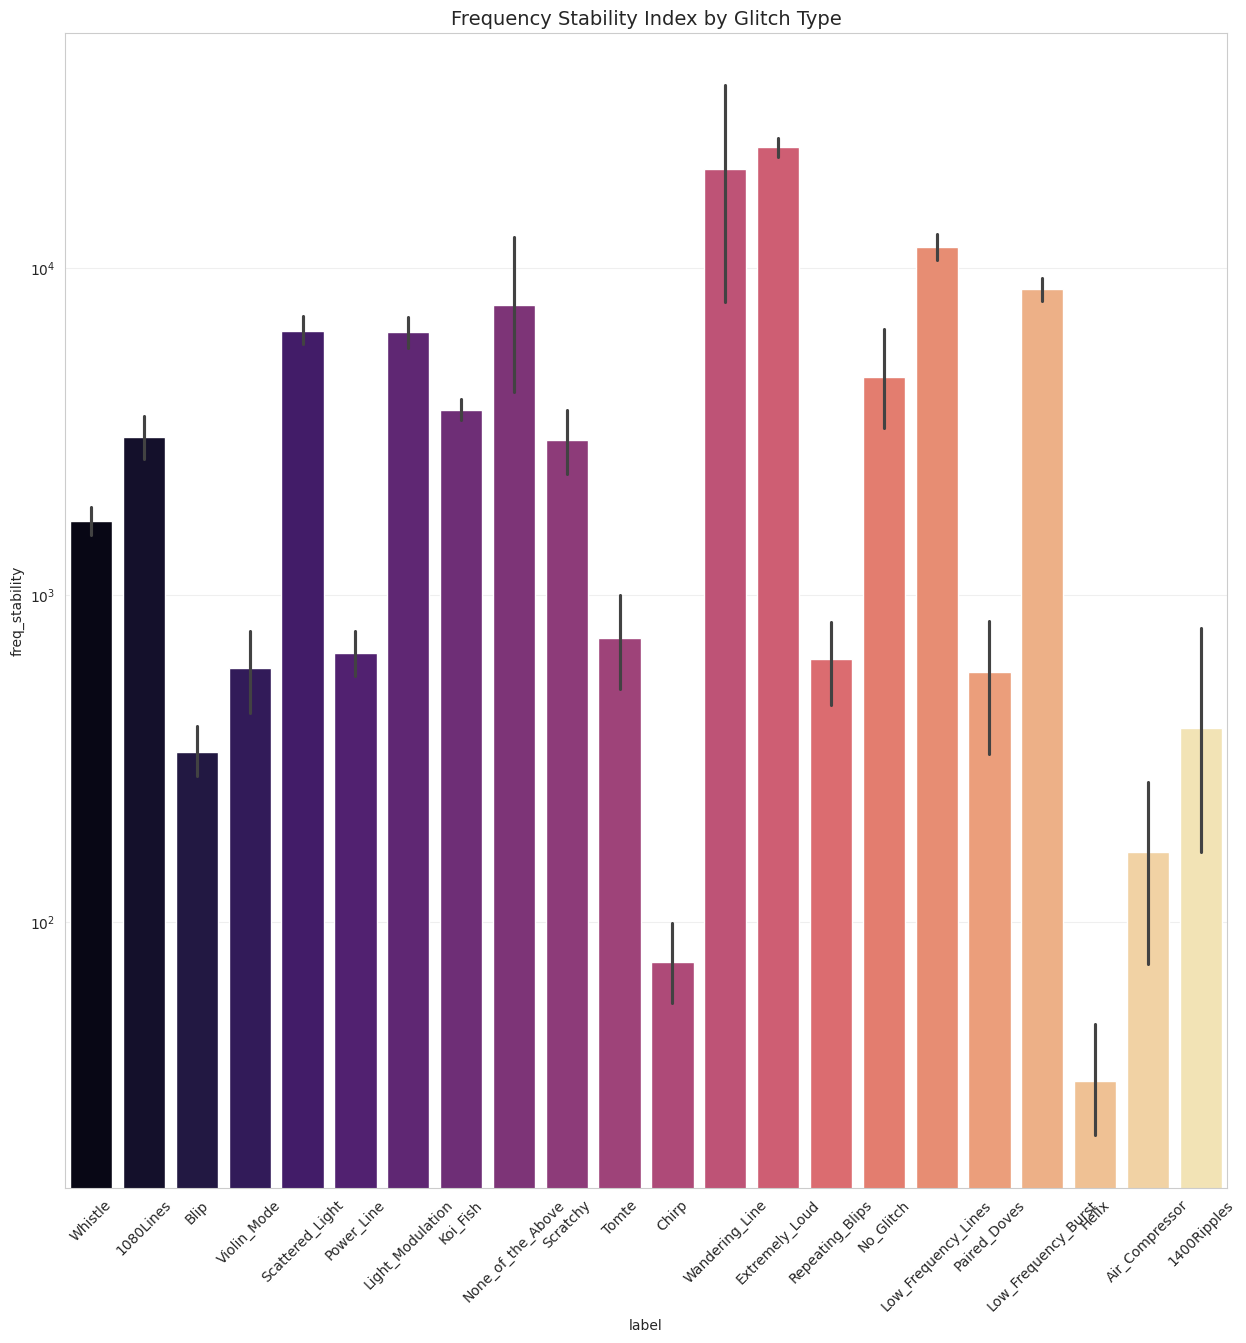

In [70]:
df['freq_stability'] = df['central_freq'] * df['duration']
plt.figure(figsize=(15,15))
sns.barplot(data=df, x='label', y='freq_stability', palette='magma')

plt.title('Frequency Stability Index by Glitch Type', fontsize=14)
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [71]:
#Acts as a data integrity indicator, helping to detect signals that maintain their central frequency over a specific duration,
#allowing the model to filter out false alarms caused by the local environment.

In [72]:
# Label Mapping 1=Gravity spay from universe 0= glitsh
df['target'] = df['label'].apply(lambda x: 1 if str(x).strip() == 'Chirp' else 0)
features = ['snr', 'peak_frequency', 'duration']

df_clean = df.dropna(subset=features + ['target']).copy()
X = df_clean[features]
y = df_clean['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

classifier.fit(X_train_resampled, y_train_resampled)


y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Glitch/Noise', 'Cosmic Signal']))
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

joblib.dump(classifier, 'ligo_classifer2_rf.pkl')

               precision    recall  f1-score   support

 Glitch/Noise       1.00      0.96      0.98      1582
Cosmic Signal       0.13      0.83      0.23        12

     accuracy                           0.96      1594
    macro avg       0.57      0.90      0.60      1594
 weighted avg       0.99      0.96      0.97      1594

Accuracy: 95.73%



['ligo_classifer2_rf.pkl']

In [81]:
classifier = joblib.load('ligo_classifer2_rf.pkl')

# snr , peak_freq, duration
sample_input = np.array([[14.3801603317261,1456.5113525390,2.0036599636077]])

prediction = classifier.predict(sample_input)[0]
probabilities = classifier.predict_proba(sample_input)[0]

if prediction == 1:
    print(f"Cosmic Signal")
    print(f"Accuracy: {probabilities[1]*100:.1f}%")
else:
    print(f"Instrumental Glitch")
    print(f"Accuracy: {probabilities[0]*100:.1f}%")

Instrumental Glitch
Accuracy: 99.1%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
